Multi-window analysis — dataset-wise (Gotham + NF-ToN + NF-BoT)

**Configurations:** 60s / 30s / 10s

Counting is **exact and vectorised** (`bincount` over floored timestamps), so it handles 35 M rows without subsampling.

**Refactored to match `0_2_Dataset_Explore` conventions:**
- Single setup cell (imports, `FIGS`/`TABLES` dirs, `save_fig`, `slug`, `save_table`)
- Per-dataset figures using the `letters = ['a','b','c','d']` naming scheme
- Results collected into one `all_results` dict, then a combined summary cell that writes JSON + CSV
- `NpEncoder` so `json.dump` doesn't crash on numpy scalars
- Guard for empty inputs in the counter; pre-built `NON_ATTACK_LIST`

## Cell 1 — Setup (imports + config + helpers)

In [ ]:
import os, glob, gc, json, warnings
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(context='paper', style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300,
                     'font.size': 10, 'axes.titlesize': 11})

FIGS   = 'figures'
TABLES = 'tables'
os.makedirs(FIGS,   exist_ok=True)
os.makedirs(TABLES, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to figures/<name>.png AND display it inline."""
    path = os.path.join(FIGS, f'{name}.png')
    fig.savefig(path, bbox_inches='tight', dpi=300)
    print(f'  saved {path}')
    plt.show()
    plt.close(fig)


def save_table(df, name):
    """Save a DataFrame to tables/<name>.csv and return it."""
    path = os.path.join(TABLES, f'{name}.csv')
    df.to_csv(path, index=True)
    print(f'  saved {path}')
    return df


def slug(name):
    """Filesystem-safe slug."""
    return name.replace(' ', '_').replace('/', '_')


class NpEncoder(json.JSONEncoder):
    """JSON encoder that tolerates numpy scalars / arrays."""
    def default(self, o):
        if isinstance(o, np.integer):  return int(o)
        if isinstance(o, np.floating): return float(o)
        if isinstance(o, np.ndarray):  return o.tolist()
        return super().default(o)


CONFIGS = [
    ("60s", 60),
    ("30s", 30),
    ("10s", 10),
]

GOTHAM_DIR = 'GothamDataset2025/processed'
NF_PATHS = {
    'nf_ton':  'NF-ToN-IoT-V3/NF-ToN-IoT-v3.csv',
    'nf_bot':  'NF-BoT-IoT-v3/NF-BoT-IoT-v3.csv',
}

NON_ATTACK_LABELS = {'Benign', 'Unknown', 'unknown', 'UNKNOWN', ''}
NON_ATTACK_LIST   = sorted(NON_ATTACK_LABELS)   # pre-built for np.isin

## Cell 2 — Helpers: exact vectorised window counting

In [ ]:
def _window_counts_fast(time_ns, codes, uniq, is_non_attack, win_sec):
    """Single-pass bincount over (window, class) pairs. No string ops."""
    win_ns = int(win_sec) * 1_000_000_000
    min_idx = int(time_ns.min()) // win_ns
    max_idx = int(time_ns.max()) // win_ns
    n_windows = int(max_idx - min_idx + 1)
    n_classes = len(uniq)

    window_idx = ((time_ns // win_ns) - min_idx).astype(np.int64)
    total_per_win = np.bincount(window_idx, minlength=n_windows)
    non_empty = total_per_win > 0

    # one pass → (n_windows, n_classes) counts
    flat = window_idx * n_classes + codes
    counts_2d = np.bincount(flat, minlength=n_windows * n_classes) \
                  .reshape(n_windows, n_classes)

    # benign window = every record in that window is a non-attack class
    na_cols = np.where(is_non_attack)[0]
    if na_cols.size:
        benign_per_win = counts_2d[:, na_cols].sum(axis=1)
        benign_windows = non_empty & (benign_per_win == total_per_win)
    else:
        benign_windows = np.zeros(n_windows, dtype=bool)

    attack_windows = non_empty & ~benign_windows

    class_counts = {}
    for j, lab in enumerate(uniq):
        if is_non_attack[j]:
            continue
        cnt = int((counts_2d[:, j] > 0).sum())
        if cnt > 0:
            class_counts[str(lab)] = cnt

    return {
        'total_windows':  int(non_empty.sum()),
        'non_empty':      int(non_empty.sum()),
        'attack_windows': int(attack_windows.sum()),
        'benign_windows': int(benign_windows.sum()),
        'counts':         class_counts,
    }


def run_all_configs(time_ns, labels, dataset_name, configs=CONFIGS):
    """Factorize labels ONCE, then run every config on the int codes."""
    # hash-based, O(n) — much faster than np.unique on object dtype
    codes, uniq = pd.factorize(labels, sort=False)
    codes = codes.astype(np.int64, copy=False)
    is_non_attack = np.array([u in NON_ATTACK_LABELS for u in uniq], dtype=bool)

    n_classes = len(uniq)
    span_h = (time_ns.max() - time_ns.min()) / 1e9 / 3600

    print(f"\n[{dataset_name}]  rows={len(time_ns):,}  "
          f"span={span_h:.2f}h  classes={n_classes}")

    out = []
    for name, win_s in configs:
        r = _window_counts_fast(time_ns, codes, uniq, is_non_attack, win_s)
        r.update({'name': name, 'win_sec': win_s, 'dataset': dataset_name})
        out.append(r)
        print(f"  {name:<22} total={r['total_windows']:>8,}  "
              f"attack={r['attack_windows']:>7,}  "
              f"benign={r['benign_windows']:>7,}")
    return out


# keep these unchanged — they only run after the counts exist
def results_to_df(results):
    return pd.DataFrame([{
        'config': r['name'],
        'total':  r['total_windows'],
        'attack': r['attack_windows'],
        'benign': r['benign_windows'],
    } for r in results])


def class_counts_to_df(results):
    all_cls = sorted(set().union(*[set(r['counts'].keys()) for r in results]))
    cols = {r['name']: [r['counts'].get(c, 0) for c in all_cls] for r in results}
    return pd.DataFrame(cols, index=all_cls)

## Cell 3 — Loaders

In [ ]:
def load_gotham():
    files = sorted(glob.glob(os.path.join(GOTHAM_DIR, '*.csv')))
    dfs = []
    for fp in tqdm(files, desc='Loading Gotham'):
        try:
            for chunk in pd.read_csv(fp,
                                     usecols=['frame.time', 'label'],
                                     low_memory=False,
                                     chunksize=1_000_000):
                dfs.append(chunk)
        except Exception as e:
            print(f"  skip {os.path.basename(fp)}: {e}")
    df = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()
    df['frame.time'] = pd.to_datetime(df['frame.time'], utc=True, format='mixed')
    time_ns = df['frame.time'].astype('int64').to_numpy()
    labels  = df['label'].astype(str).to_numpy()
    return time_ns, labels


def load_nf(path):
    dfs = []
    for chunk in pd.read_csv(path,
                             usecols=['FLOW_START_MILLISECONDS', 'Attack'],
                             low_memory=False,
                             chunksize=2_000_000):
        dfs.append(chunk)
    df = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()
    time_ns = (pd.to_numeric(df['FLOW_START_MILLISECONDS'], errors='coerce')
                 .fillna(0).astype('int64') * 1_000_000).to_numpy()
    labels  = df['Attack'].fillna('Unknown').astype(str).to_numpy()
    return time_ns, labels

## Cell 4 — GOTHAM (packet-level)

In [ ]:
print('GOTHAM  (packet-level, frame.time)')

time_ns, labels = load_gotham()
print(f"  total packets: {len(time_ns):,}")
print(f"  label distribution: {Counter(labels).most_common()}")
gotham_results = run_all_configs(time_ns, labels, 'gotham')
del time_ns, labels; gc.collect()

GOTHAM  (packet-level, frame.time)


Loading Gotham: 100%|██████████| 78/78 [01:08<00:00,  1.14it/s]


  total packets: 35,134,281
  label distribution: [('Benign', 12256883), ('Mirai UDP Flooding', 8897895), ('Mirai TCP Flooding', 6548173), ('Mirai GRE Flooding', 5911401), ('TCP Scan', 737764), ('CoAP Amplification', 274837), ('Telnet Brute Force', 227649), ('Merlin TCP Flooding', 120000), ('Merlin ICMP Flooding', 57580), ('Merlin UDP Flooding', 29996), ('Merlin C&C Communication', 29356), ('Ingress Tool Transfer', 21587), ('Unknown', 7670), ('File Download', 7196), ('UDP Scan', 4242), ('Mirai C&C Communication', 1074), ('C&C Communication', 528), ('Reporting', 450)]

[gotham]  rows=35,134,281  span=265.10h  classes=18
  60s                    total=     673  attack=    251  benign=    422
  30s                    total=   1,332  attack=    491  benign=    841
  10s                    total=   3,960  attack=  1,238  benign=  2,722


0

## Cell 5 — NF-ToN-IoT-V3

In [ ]:
print('NF-ToN-IoT-V3  (flow-level, FLOW_START_MILLISECONDS)')

time_ns, labels = load_nf(NF_PATHS['nf_ton'])
print(f"  total flows: {len(time_ns):,}")
print(f"  label distribution: {Counter(labels).most_common()}")
ton_results = run_all_configs(time_ns, labels, 'nf_ton')
del time_ns, labels; gc.collect()

NF-ToN-IoT-V3  (flow-level, FLOW_START_MILLISECONDS)
  total flows: 27,520,260
  label distribution: [('Benign', 16792214), ('ddos', 4141256), ('xss', 2834435), ('password', 1594777), ('scanning', 1358977), ('injection', 381777), ('dos', 203456), ('Backdoor', 203384), ('mitm', 6013), ('ransomware', 3971)]

[nf_ton]  rows=27,520,260  span=144.60h  classes=10
  60s                    total=   5,633  attack=  5,328  benign=    305
  30s                    total=  11,219  attack= 10,319  benign=    900
  10s                    total=  33,457  attack= 29,576  benign=  3,881


0

## Cell 6 — NF-BoT-IoT-V3

In [ ]:
print('NF-BoT-IoT-V3  (flow-level, FLOW_START_MILLISECONDS)')

time_ns, labels = load_nf(NF_PATHS['nf_bot'])
print(f"  total flows: {len(time_ns):,}")
print(f"  label distribution: {Counter(labels).most_common()}")
bot_results = run_all_configs(time_ns, labels, 'nf_bot')
del time_ns, labels; gc.collect()

NF-BoT-IoT-V3  (flow-level, FLOW_START_MILLISECONDS)
  total flows: 16,933,808
  label distribution: [('DoS', 8034190), ('DDoS', 7150882), ('Reconnaissance', 1695132), ('Benign', 51989), ('Theft', 1615)]

[nf_bot]  rows=16,933,808  span=843.83h  classes=5
  60s                    total=   1,470  attack=  1,155  benign=    315
  30s                    total=   2,777  attack=  2,212  benign=    565
  10s                    total=   7,589  attack=  6,072  benign=  1,517


0

## Cell 8 — Combined summary + JSON + tables

In [ ]:
all_results = {
    'gotham':  gotham_results,
    'nf_ton':  ton_results,
    'nf_bot':  bot_results,
}

for ds_name, res in all_results.items():
    print(f"\n{'=' * 90}\n{ds_name.upper()}  -- window summary\n{'=' * 90}")
    df = results_to_df(res)
    print(df.to_string(index=False))
    save_table(df, f'MW_window_summary_{slug(ds_name)}')

    print(f"\n--- {ds_name}: per-class window counts ---")
    df_c = class_counts_to_df(res)
    print(df_c.to_string())
    save_table(df_c, f'MW_perclass_counts_{slug(ds_name)}')

# --- JSON dump (NpEncoder handles numpy scalars) ---
summary = {
    ds_name: {
        'window_summary': results_to_df(res).to_dict(orient='records'),
        'per_class':      class_counts_to_df(res).to_dict(),
    }
    for ds_name, res in all_results.items()
}
with open('multi_window_results_nonoverlap.json', 'w') as f:
    json.dump(summary, f, indent=2, cls=NpEncoder)
print('\nSaved multi_window_results_nonoverlap.json')


GOTHAM  -- window summary
config  total  attack  benign
   60s    673     251     422
   30s   1332     491     841
   10s   3960    1238    2722
  saved tables\MW_window_summary_gotham.csv

--- gotham: per-class window counts ---
                          60s  30s  10s
C&C Communication          19   34   79
CoAP Amplification          1    2    2
File Download               5    5    5
Ingress Tool Transfer      15   29   82
Merlin C&C Communication   71  141  415
Merlin ICMP Flooding        6    6    7
Merlin TCP Flooding         7    8    9
Merlin UDP Flooding         3    3    3
Mirai C&C Communication   115  226  457
Mirai GRE Flooding          8   11   12
Mirai TCP Flooding          6    7   13
Mirai UDP Flooding         17   21   30
Reporting                  13   23   37
TCP Scan                   19   34   93
Telnet Brute Force         24   47  139
UDP Scan                   37   71  205
  saved tables\MW_perclass_counts_gotham.csv

NF_TON  -- window summary
config  total  a

## Cell 9 — Per-dataset heatmaps: per-class window counts

One PNG per dataset, matching the explorer's `F1a/F1b/...` convention.

Outputs: `MW1a_perclass_gotham.png`, `MW1b_perclass_nf_ton.png`, …

  saved figures\MW1a_perclass_gotham.png


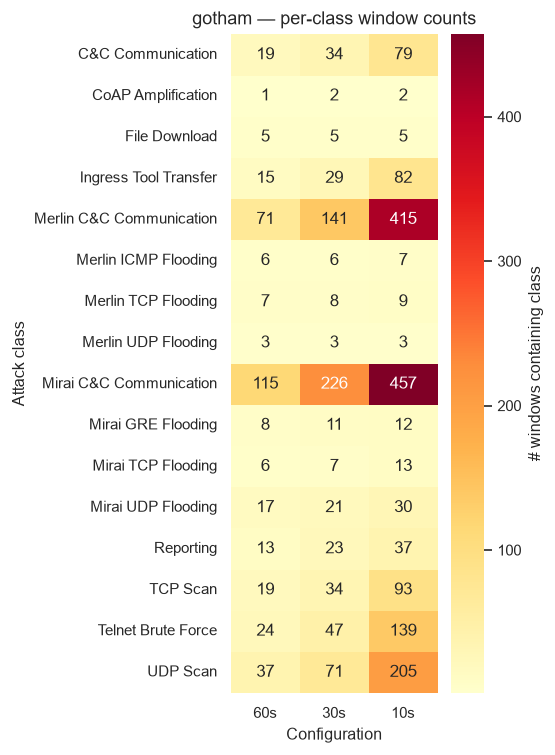

  saved figures\MW1b_perclass_nf_ton.png


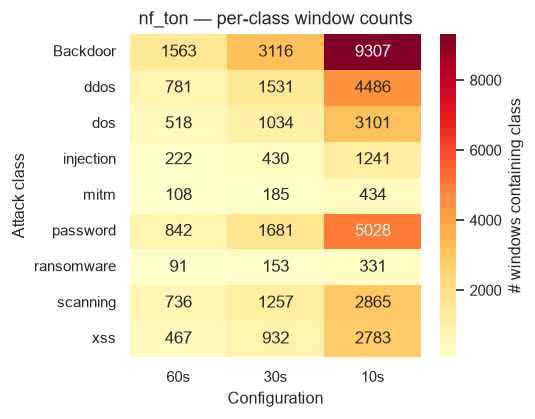

  saved figures\MW1c_perclass_nf_bot.png


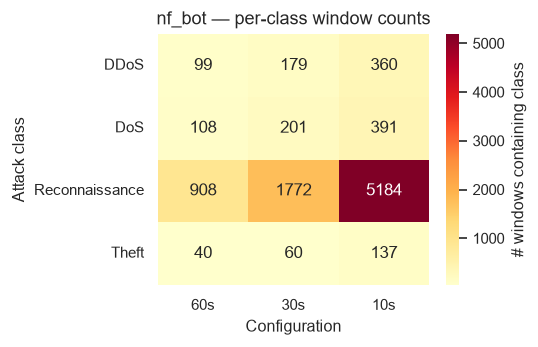

In [ ]:
letters = ['a', 'b', 'c', 'd']

for i, (ds_name, res) in enumerate(all_results.items()):
    df_h = class_counts_to_df(res)
    if df_h.empty:
        print(f'  {ds_name}: no attack windows — skipping heatmap')
        continue

    fig, ax = plt.subplots(figsize=(4.5, max(3.0, 0.4 * len(df_h))))
    sns.heatmap(df_h, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': '# windows containing class'})
    ax.set_title(f'{ds_name} — per-class window counts')
    ax.set_xlabel('Configuration')
    ax.set_ylabel('Attack class')
    plt.tight_layout()
    save_fig(fig, f'MW1{letters[i]}_perclass_{slug(ds_name)}')

## Cell 10 — Per-dataset min / median / max of per-class counts

Outputs: `MW2a_windowstats_gotham.png`, `MW2b_windowstats_nf_ton.png`, …

  saved figures\MW2a_windowstats_gotham.png


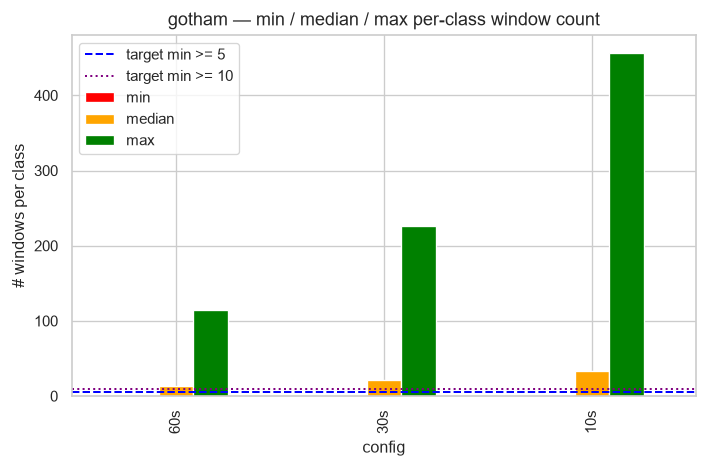

  saved figures\MW2b_windowstats_nf_ton.png


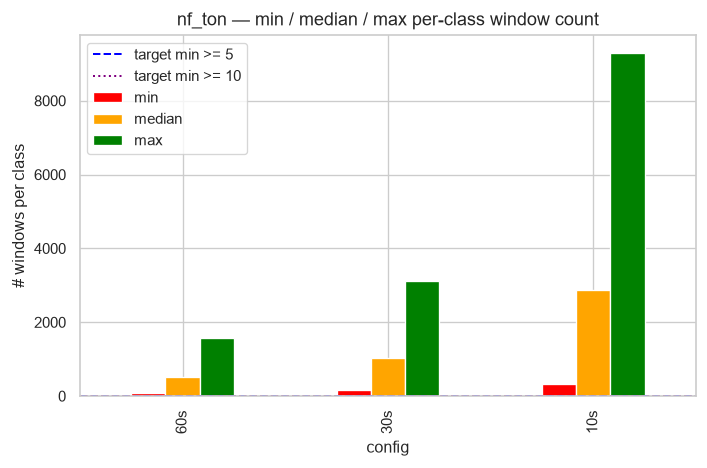

  saved figures\MW2c_windowstats_nf_bot.png


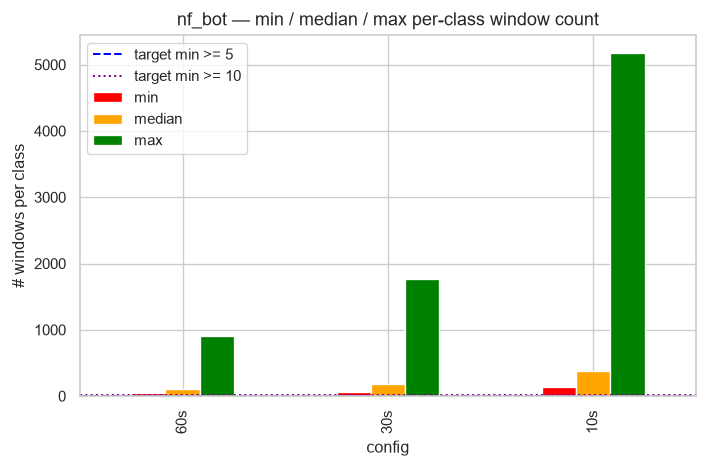

In [ ]:
letters = ['a', 'b', 'c', 'd']

for i, (ds_name, res) in enumerate(all_results.items()):
    stats = []
    for r in res:
        vals = list(r['counts'].values())
        if vals:
            stats.append([r['name'], min(vals), int(np.median(vals)), max(vals)])
        else:
            stats.append([r['name'], 0, 0, 0])
    sdf = (pd.DataFrame(stats,
                        columns=['config', 'min', 'median', 'max'])
             .set_index('config'))

    fig, ax = plt.subplots(figsize=(6, 4))
    sdf.plot(kind='bar', ax=ax, color=['red', 'orange', 'green'])
    ax.axhline(5,  color='blue',   linestyle='--', label='target min >= 5')
    ax.axhline(10, color='purple', linestyle=':',  label='target min >= 10')
    ax.set_title(f'{ds_name} — min / median / max per-class window count')
    ax.set_ylabel('# windows per class')
    ax.legend()
    plt.tight_layout()
    save_fig(fig, f'MW2{letters[i]}_windowstats_{slug(ds_name)}')